# Saturation Effect in EPR: Spin-1/2 System

**Purpose**  
This notebook demonstrates the saturation effect in electron paramagnetic resonance (EPR) for a simple S=1/2 spin system.  
When a strong microwave field (B₁) is applied, the population difference between spin levels decreases, reducing the EPR signal. This phenomenon is quantified by the saturation parameter

\[
S = \omega_1^2 \, T_1 T_2
\]

where \(\omega_1 = \gamma B_1\) is the Rabi frequency, \(T_1\) is the spin‑lattice relaxation time, and \(T_2\) is the transverse relaxation time.

**What we do**  
- Define a single electron spin (S=1/2) with realistic relaxation rates.  
- Vary the microwave field strength \(B_1\) (and thus \(\omega_1\)).  
- Simulate time‑resolved EPR signals using a density‑matrix approach.  
- Extract the effective \(T_1\) from the signal decay and compare it with the theoretical prediction \(T_{1,\text{eff}} = T_1 / (1+S)\).

**Expected behaviour**  
As \(S\) increases, the effective \(T_1\) should shorten exactly as \(T_1/(1+S)\), confirming the the correct implementation of the B1 - field.


In [1]:
import sys
import os
import math
from importlib import reload

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

import torch
import numpy as np
import matplotlib.pyplot as plt
from mars import spin_model
from mars.population.contexts import Context
import mars

dtype = torch.float64
device = torch.device("cpu")

### 1. S=1/2

In [2]:
g_tensor = spin_model.Interaction((2.0023, 2.0023, 2.0023), dtype=dtype)

base_system = spin_model.SpinSystem(
    electrons=[0.5],
    g_tensors=[g_tensor],
    dtype=dtype,
)

sample = spin_model.MultiOrientedSample(
    base_spin_system=base_system,
    gauss=0.001, lorentz=0.0, mesh=(10, 10),
    dtype=dtype,
)

In [3]:
W_pop = 1e3              # Population transfer rate [s⁻¹]
gamma_dephasing = 1e6    # Pure dephasing [s⁻¹]

free_probs = torch.tensor([
    [0.0, W_pop],
    [W_pop, 0.0]
], dtype=dtype)

context = Context(
    basis="zeeman",
    sample=sample,
    init_populations=[0.0, 1.0],  # inverted state
    free_probs=free_probs,
    dephasing=[gamma_dephasing, gamma_dephasing],
    enforce_secularity=True,
    dtype=dtype
)

T1 = 1.0 / (2 * W_pop)
T2 = 1.0 / (W_pop/2 + gamma_dephasing)

print(f"T₁ = {T1:.3e} s")
print(f"T₂ = {T2:.3e} s")

T₁ = 5.000e-04 s
T₂ = 9.995e-07 s


In [4]:
omega_1 = np.logspace(3, 5.3, 300)
S = (omega_1**2) * T1 * T2
T1_eff = [T1 / (1 + s) for s in S]

w1_sat = np.sqrt(1.0 / (T1 * T2))
print(f"Saturation threshold: ω₁,sat = {w1_sat:.2e} rad/s")

Saturation threshold: ω₁,sat = 4.47e+04 rad/s


**Note**
Under rotating wave approximation we use B1 as the amplitude of the full magnetic field. This yields two counter-rotating components, each with amplitude b1_field/2. Only the resonant component (rotating in the same direction as the spin precession) is retained. Therefore, the effective static field in the
rotating frame is exactly half of the lab-frame amplitude.

In [5]:
b1_field_rotating = mars.constants.unit_converter(omega_1 / (2 * math.pi), "Hz_to_T_e") / 2.0023
b1_field = b1_field_rotating * 2

In [ ]:
out = []

for omega_intensity, b1 in zip(omega_1, b1_field):
    loop_res = {}
    
    loop_res["w"] = omega_intensity
    S = (omega_intensity**2) * T1 * T2
    loop_res["S"] = S
    populator = mars.population.RWADensityPopulator(
            context=context, init_temperature=4.0, difference_out=False,
            b1_field=b1,
            dtype=dtype, device=device
        )


    tr_spectra_creator = mars.spectra_manager.DensityTimeSpectra(
        freq=9.8e9,    # Frequency in Hz 
        sample=sample,
        harmonic=0, # absorbtion
        context=context,
        temperature=4.0,
        populator = populator,
    #    hamiltonian_mode="direct",
        device=device,
        dtype=dtype
    )

    # Define magnetic field range for simulation
    fields = torch.linspace(0.3485, 0.351, 300, dtype=dtype, device=device)  # Field in Tesla

    # Time axes in long and short time scale
    tot_points = 500
    time = torch.linspace(0.0, 4 * 1e-3, tot_points, dtype=dtype, device=device)  # time in seconds, long time scale, up to 70ms
    time = torch.cat((time, torch.tensor([1e-3, 1e-2, 1e-1, 1.0], dtype=dtype, device=device)))

    # Compute 2D spectra
    spectrum_pop  = tr_spectra_creator(sample, fields, time)
    spectrum_pop = spectrum_pop - spectrum_pop[-1]
    spectrum_pop = spectrum_pop[:-4]
    spectrum_pop = spectrum_pop / -spectrum_pop.min()
    time = time[:-4]
    loop_res["time"] = time
    loop_res["spec"] = spectrum_pop
    
    out.append(loop_res)

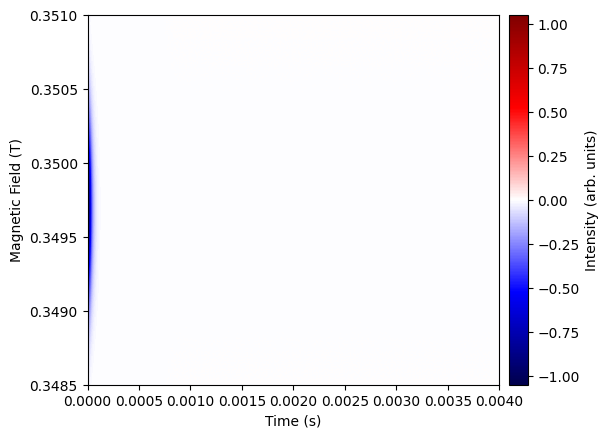

In [7]:
mars.visualization.plot_2d_timeresolved(fields, time, out[-1]["spec"])

In [8]:
fields[150]

tensor(0.3498, dtype=torch.float64)

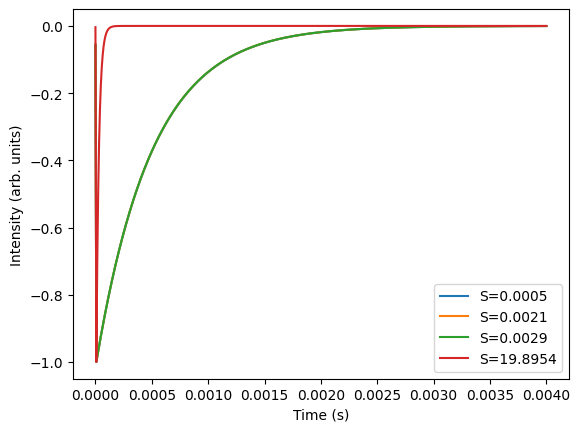

In [9]:
field_val = 0.3497
S = [res["S"] for res in out]

field_idx = 15

mars.visualization.plot_kinetic(field_val, fields, time, out[0]["spec"], label=f"S={S[0]:.4f}")
mars.visualization.plot_kinetic(field_val, fields, time, out[40]["spec"], label=f"S={S[40]:.4f}")
mars.visualization.plot_kinetic(field_val, fields, time, out[50]["spec"], label=f"S={S[50]:.4f}")
mars.visualization.plot_kinetic(field_val, fields, time, out[-1]["spec"], label=f"S={S[-1]:.4f}")

In [10]:
time = time[10:]

kinetics = []
for res in out:
    kinetics.append(
        res["spec"][10:, 150]
    )

In [11]:
from scipy.optimize import curve_fit

def mono_exp(t, A, T1, offset):
    return offset + A * np.exp(-t / T1)

popt, pcov = curve_fit(mono_exp, time, -kinetics[0], p0=[1.0, 1e-3, 0.0])
T1_fitted = popt[1]

## 8. Comparison: fitted \(T_1\) vs. theoretical \(T_{1,\text{eff}}\)

The plot shows the ratio \(T_{1,\text{fitted}} / T_{1,\text{eff}}\) as a function of the saturation parameter \(S\).  
If the simulation matches theory, the ratio should stay close to **1** over the whole range.  
Any deviation would indicate numerical or modelling issues – but here we expect excellent agreement.

In [12]:
T1_fitted = []
for kinet in kinetics:
    popt, pcov = curve_fit(mono_exp, time, -kinet, p0=[1.0, 1e-3, 0.0])
    T1_fitted.append(
        popt[1]
    )

C:\Users\User\AppData\Local\Temp\ipykernel_16544\1364602774.py:4: RuntimeWarning: overflow encountered in exp
  return offset + A * np.exp(-t / T1)


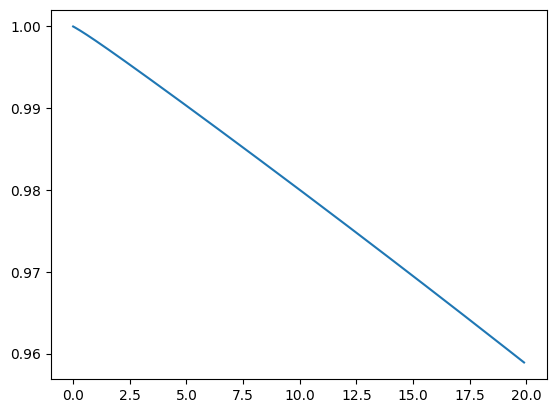

In [13]:
plt.plot(S, np.array(T1_fitted) / np.array(T1_eff))

The fitted effective \(T_1\) follows the theoretical \(T_1/(1+S)\) behaviour, confirming that implementation correctly captures the saturation effect for an S=1/2 system.

# RWA and propagator comparison

In [14]:
S = (w1_sat**2) * T1 * T2
print(S)

0.9999999999999998


### RWA

In [15]:
b1_field = mars.constants.unit_converter(w1_sat / (2 * math.pi), "Hz_to_T_e") / 2.0023


S = (omega_intensity**2) * T1 * T2
populator = mars.population.RWADensityPopulator(
        context=context, init_temperature=4.0, difference_out=False,
        b1_field=b1_field,
        dtype=dtype, device=device
    )


tr_spectra_creator = mars.spectra_manager.DensityTimeSpectra(
    freq=9.8e9,    # Frequency in Hz 
    sample=sample,
    harmonic=0, # absorbtion
    context=context,
    temperature=4.0,
    populator = populator,
#    hamiltonian_mode="direct",
    device=device,
    dtype=dtype
)

# Define magnetic field range for simulation
fields = torch.linspace(0.3485, 0.351, 300, dtype=dtype, device=device)  # Field in Tesla

# Time axes in long and short time scale
tot_points = 500
time = torch.linspace(0.0, 4 * 1e-3, tot_points, dtype=dtype, device=device)  # time in seconds, long time scale, up to 70ms
time = torch.cat((time, torch.tensor([1e-3, 1e-2, 1e-1, 1.0], dtype=dtype, device=device)))

# Compute 2D spectra
spectrum_rwa  = tr_spectra_creator(sample, fields, time)
spectrum_rwa = spectrum_rwa - spectrum_rwa[-1]
spectrum_rwa = spectrum_rwa[:-4]
spectrum_rwa = spectrum_rwa / -spectrum_rwa.min()
time = time[:-4]

In [16]:
b1_field = mars.constants.unit_converter(w1_sat / (2 * math.pi), "Hz_to_T_e") / 2.0023


S = (omega_intensity**2) * T1 * T2
populator = mars.population.PropagatorDensityPopulator(
        context=context, init_temperature=4.0, difference_out=False,
        b1_field=b1_field,
        dtype=dtype, device=device
    )


tr_spectra_creator = mars.spectra_manager.DensityTimeSpectra(
    freq=9.8e9,    # Frequency in Hz 
    sample=sample,
    harmonic=0, # absorbtion
    context=context,
    temperature=4.0,
    populator = populator,
#    hamiltonian_mode="direct",
    device=device,
    dtype=dtype
)

# Define magnetic field range for simulation
fields = torch.linspace(0.3485, 0.351, 300, dtype=dtype, device=device)  # Field in Tesla

# Time axes in long and short time scale
tot_points = 500
time = torch.linspace(0.0, 4 * 1e-3, tot_points, dtype=dtype, device=device)  # time in seconds, long time scale, up to 70ms
time = torch.cat((time, torch.tensor([1e-3, 1e-2, 1e-1, 1.0], dtype=dtype, device=device)))

# Compute 2D spectra
spectrum_prop  = tr_spectra_creator(sample, fields, time)
spectrum_prop = spectrum_prop - spectrum_prop[-1]
spectrum_prop = spectrum_prop[:-4]
spectrum_prop = spectrum_prop / -spectrum_prop.min()
time = time[:-4]

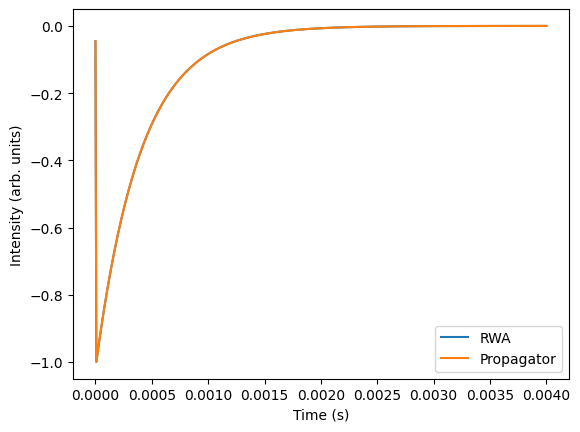

In [18]:
field_val = 0.3497

mars.visualization.plot_kinetic(field_val, fields, time, spectrum_rwa, label=f"RWA")
mars.visualization.plot_kinetic(field_val, fields, time, spectrum_prop, label=f"Propagator")

### The results are the same!!!!